## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


## Read the data 

In [3]:
Data = pd.read_csv(r'D:\AI\ai_deploma_master\ai_deploma_master\files\creditcard.csv')
#https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [4]:
Data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
data=Data.drop(['Time'],axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


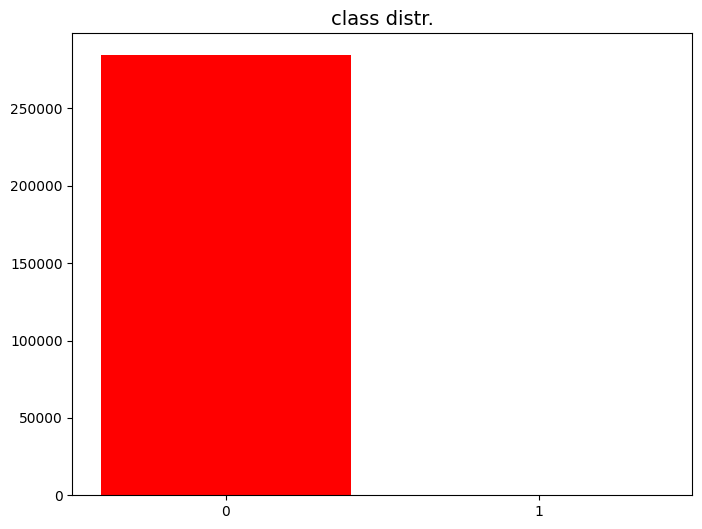

In [6]:
from matplotlib import rcParams
rcParams['figure.figsize']=8,6
plt.bar(data['Class'].unique(),data['Class'].value_counts(),color=['red','green'])
plt.xticks([0,1])
plt.title('class distr.',fontsize=14)
plt.show()

In [7]:
x=data.drop(['Class'] ,axis=1)
y=data['Class']

In [8]:
x_train , x_test , y_train , y_test = train_test_split(x,y,train_size=0.8,random_state = 10)

In [17]:
Hp_params={'critertion':['gini','entropy'],'max_depth':[1,2,3,4,5,10,15,20]}
tree_GS_param=GridSearchCV(DecisionTreeClassifier(),Hp_params,cv=5,scoring='roc_auc',n_jobs=1,verbose=1)
Hp_params={'criterion':['gini','entropy'],'max_depth':[1,2,3,4,5,10,15,20]}
tree_GS_param=GridSearchCV(DecisionTreeClassifier(),Hp_params,cv=5,scoring='roc_auc',n_jobs=1,verbose=1)
tree_GS_param.fit(x_train,y_train)
print("the best parameter combination  ")
print(tree_GS_param.best_score_,tree_GS_param.best_score_)
print("the best parameter combination  ")
print(tree_GS_param.best_score_,tree_GS_param.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
the best parameter combination  
0.9320781539161638 0.9320781539161638
the best parameter combination  
0.9320781539161638 0.9320781539161638


In [19]:
y_pred =tree_GS_param.predict(x_test)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56861     7]
 [   20    74]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56868
       Fraud       0.91      0.79      0.85        94

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9995259997893332
Sensitivity :  0.9998769079271295
Specificity :  0.7872340425531915


In [24]:
pip install IPython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz
from IPython.display import Image


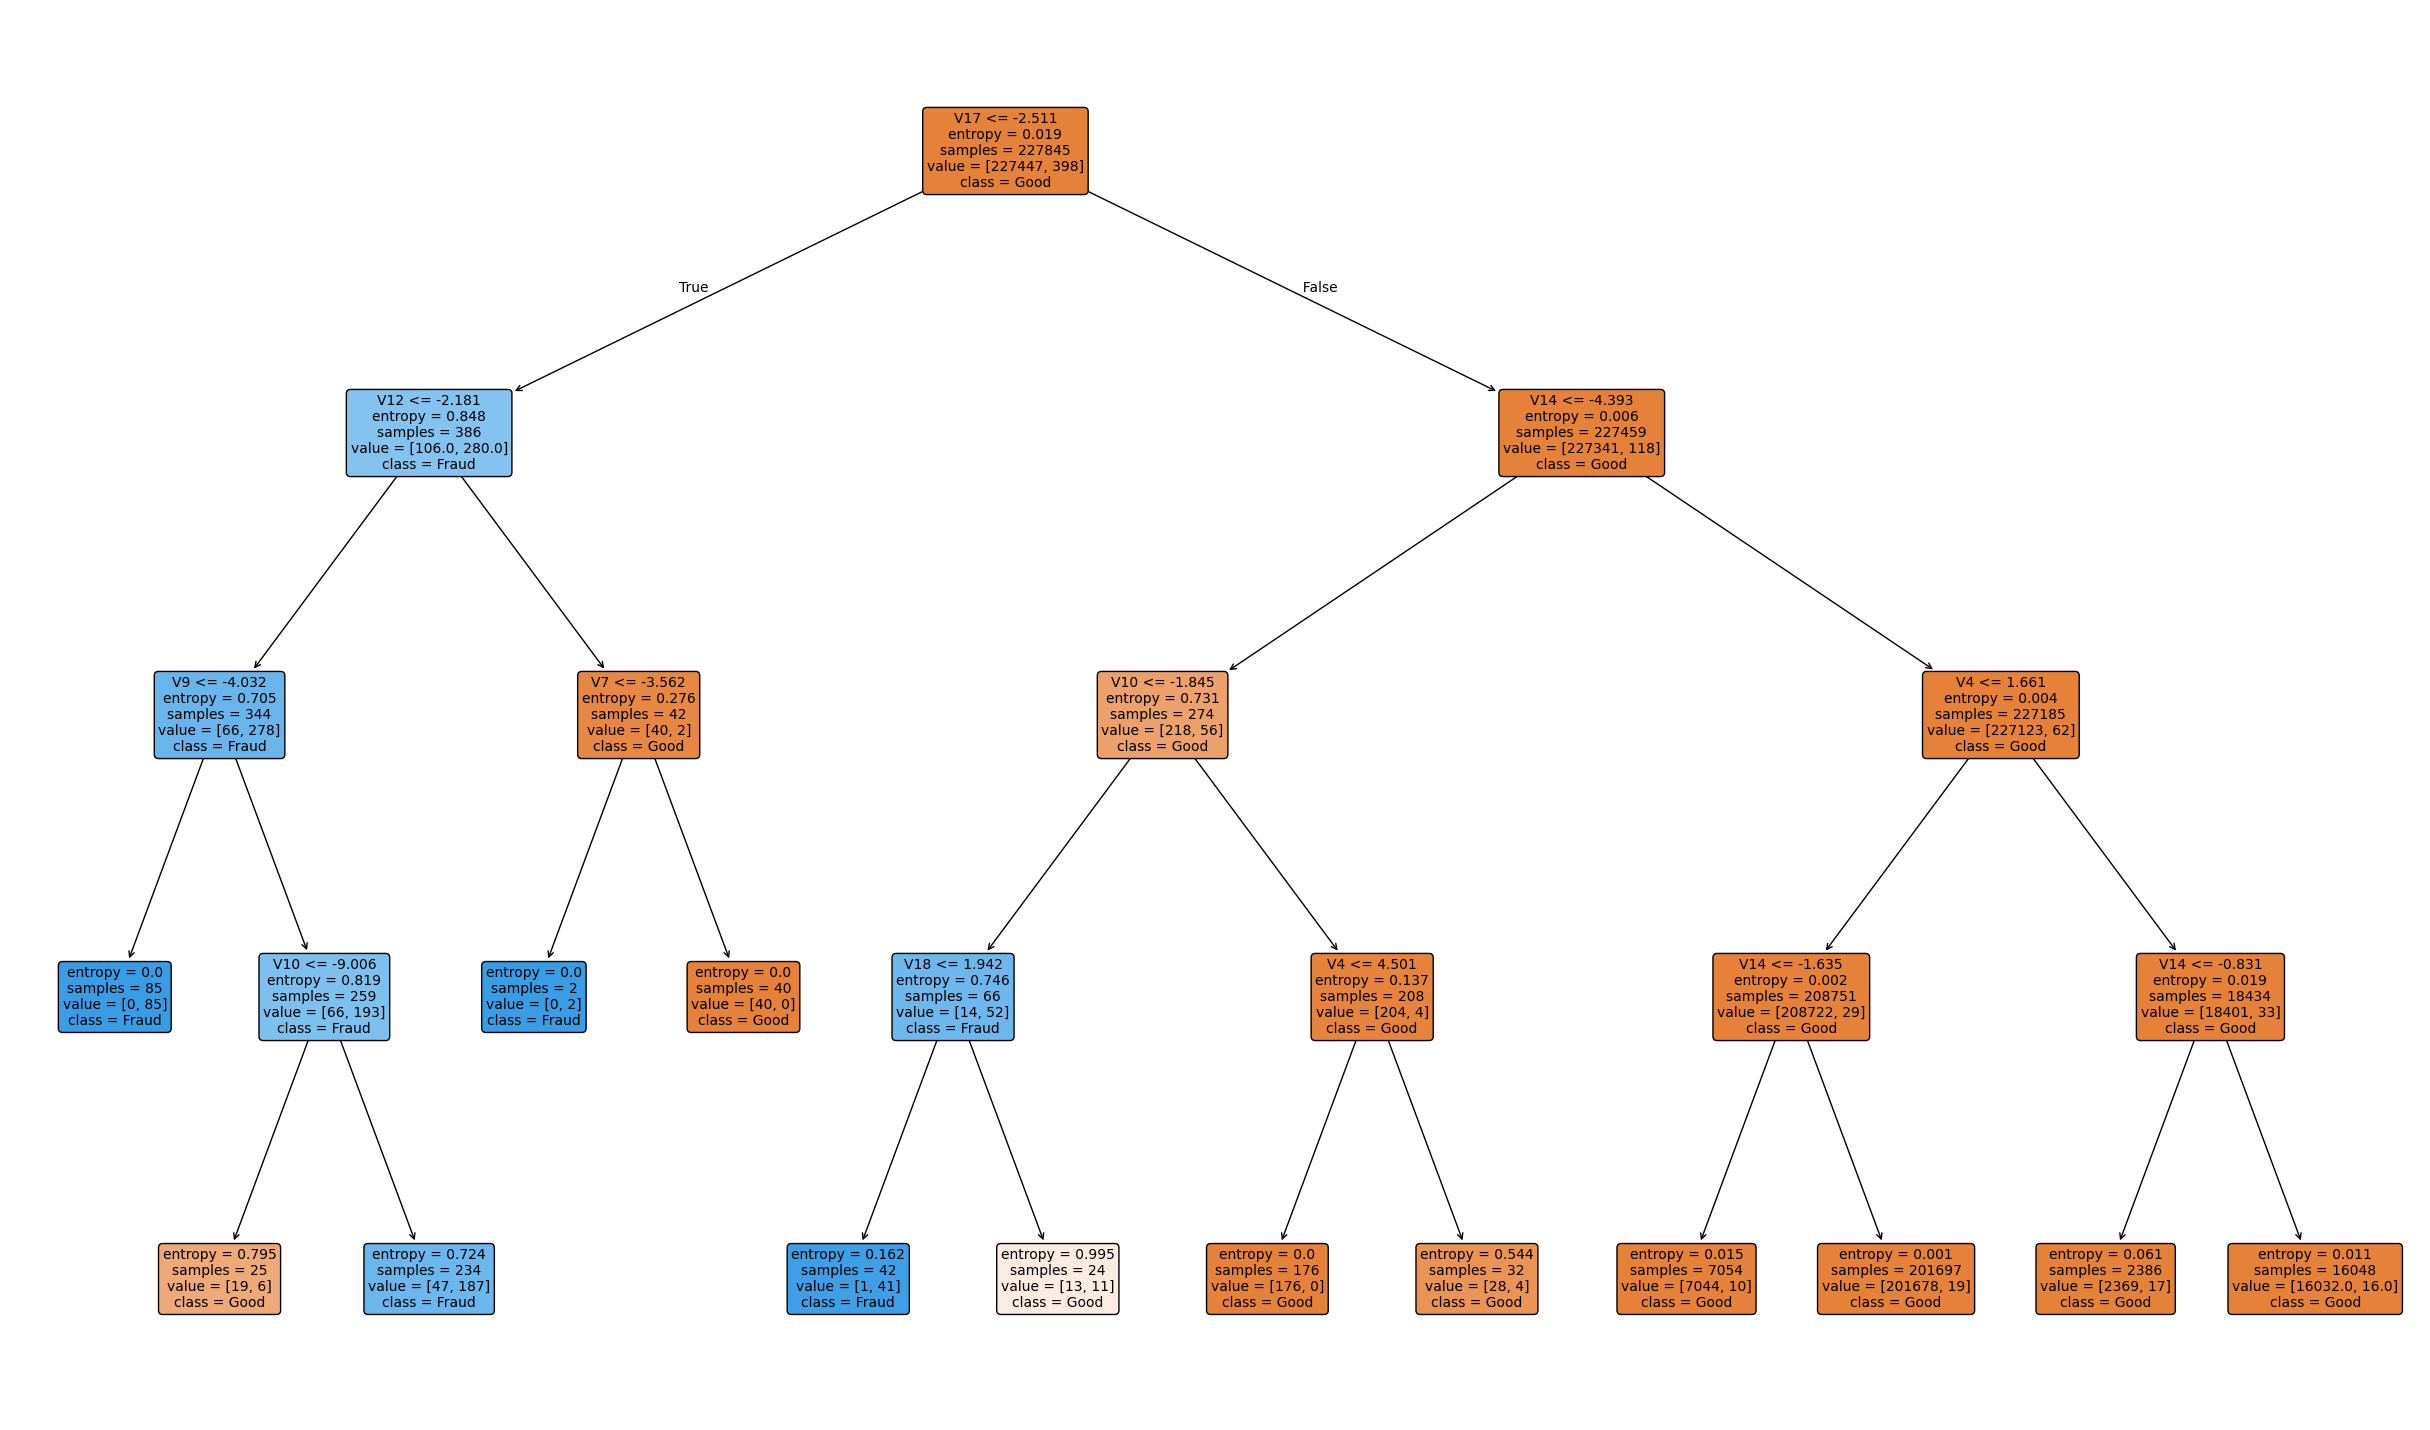

In [34]:
#alternative way to visualize the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a large figure for better readability
plt.figure(figsize=(25, 15))

# Plot the decision tree
plot_tree(tree_GS_param.best_estimator_, 
          feature_names=x.columns.tolist(),
          class_names=["Good", "Fraud"],
          filled=True,
          rounded=True,
          fontsize=10)

plt.tight_layout()
plt.savefig('Credit.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x800 with 0 Axes>

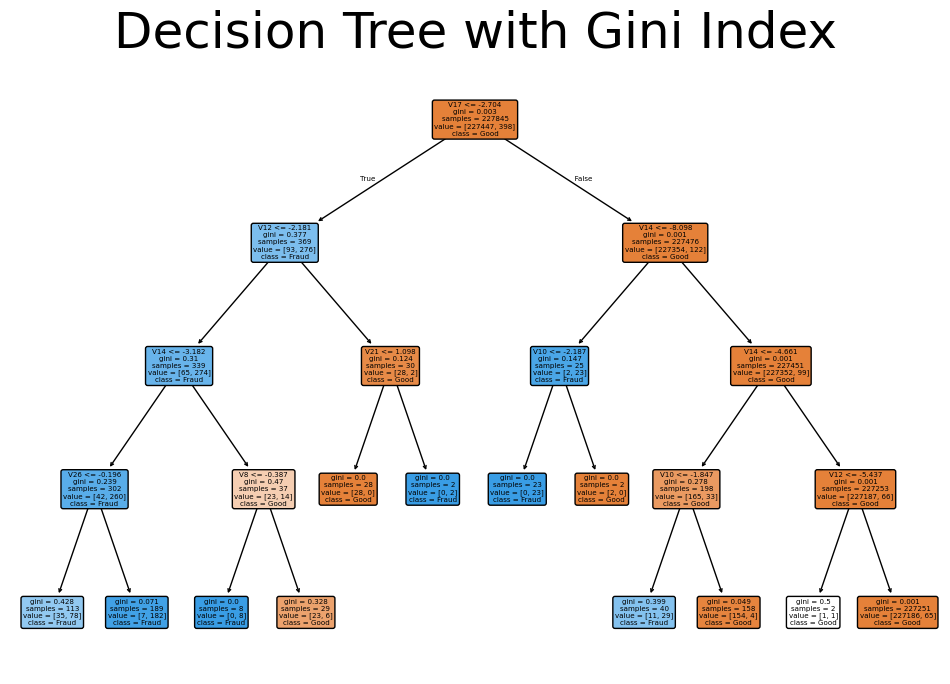

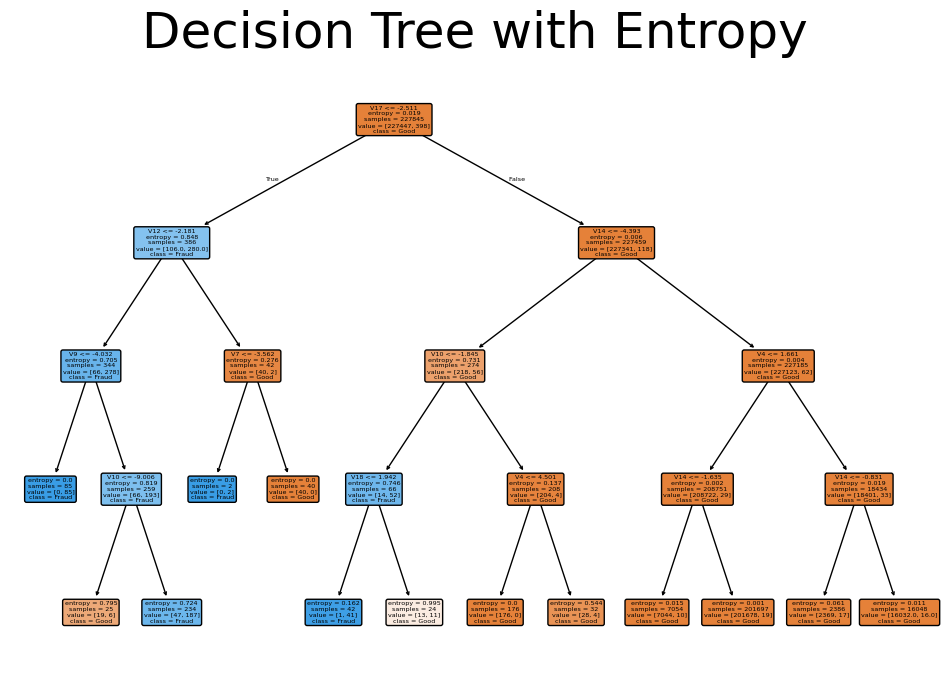

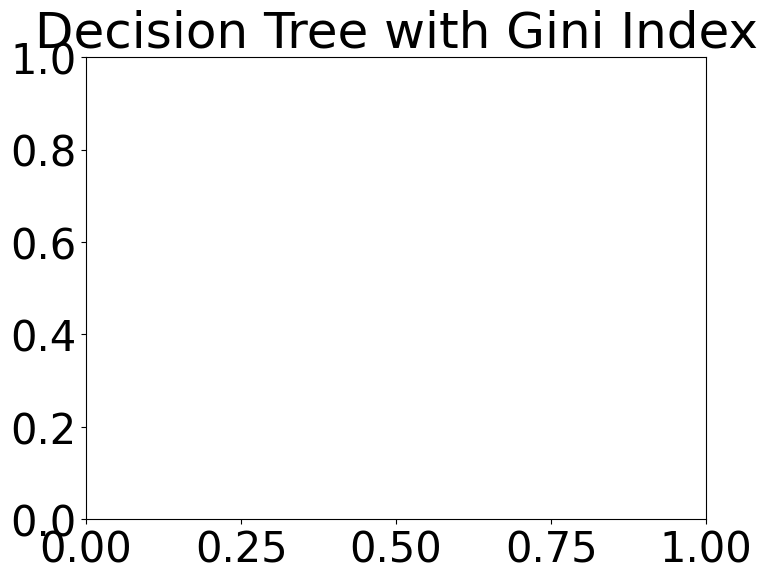

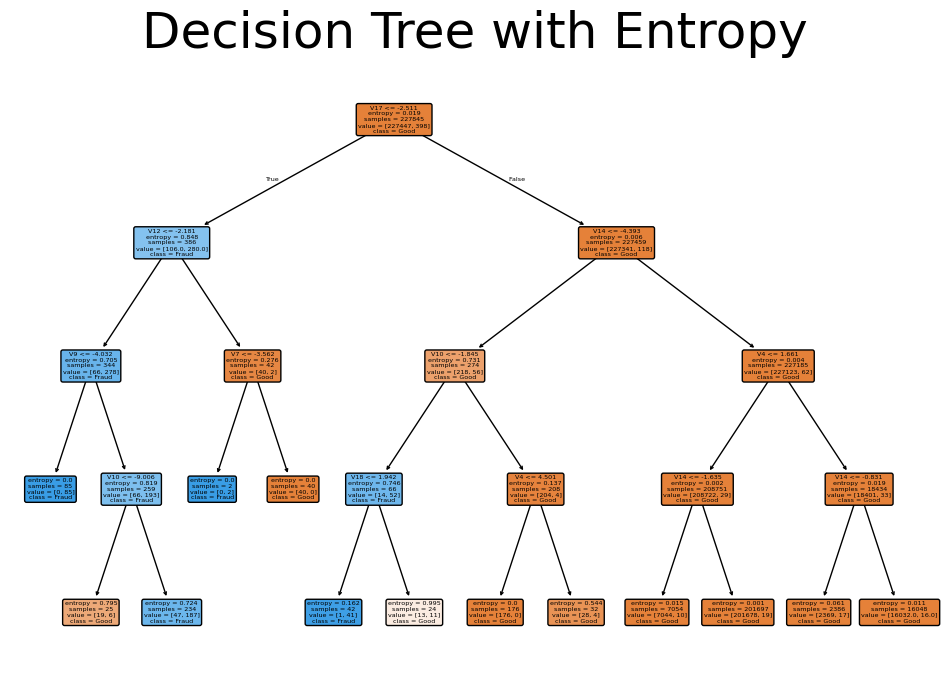

In [38]:
from sklearn import tree 
plt.figure(figsize=(12,8))
plt.figure(figsize=(12,8))

clf = DecisionTreeClassifier(criterion='gini',
                             max_depth=tree_GS_param.best_params_['max_depth'],
                             random_state=10)
clf.fit(x_train, y_train)

tree.plot_tree(clf, filled=True, feature_names=x.columns, class_names=["Good", "Fraud"], rounded=True)
plt.title("Decision Tree with Gini Index")
plt.show()

plt.figure(figsize=(12,8))

clf1 = DecisionTreeClassifier(criterion='entropy',
                              max_depth=tree_GS_param.best_params_['max_depth'],
                              random_state=10)
clf1.fit(x_train, y_train)

tree.plot_tree(clf1, filled=True, feature_names=x.columns, class_names=["Good", "Fraud"], rounded=True)
plt.title("Decision Tree with Entropy")
plt.show()
plt.title("Decision Tree with Gini Index")
plt.show()
plt.figure(figsize=(12,8))
tree.plot_tree(clf1, filled=True, feature_names=x.columns, class_names=["Good", "Fraud"], rounded=True)
plt.title("Decision Tree with Entropy")
plt.show()


In [32]:
#https://matplotlib.org/3.1.1/gallery/color/colormap_reference.html
import numpy as np

def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / np.sum(cm).astype('float')
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('cool') ##https://matplotlib.org/3.1.1/gallery/color/colormap_reference.html

    plt.figure(figsize=(20, 20))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    #plt.ylabel('True label', fontsize=35)
    #plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:100.4f}'.format(accuracy, misclass), fontsize=35)
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:100.4f}'.format(accuracy, misclass))
    plt.show()
    
    
# Modify the default matplotlib parameters for the desired fontsize
plt.rcParams.update({'font.size': 30})

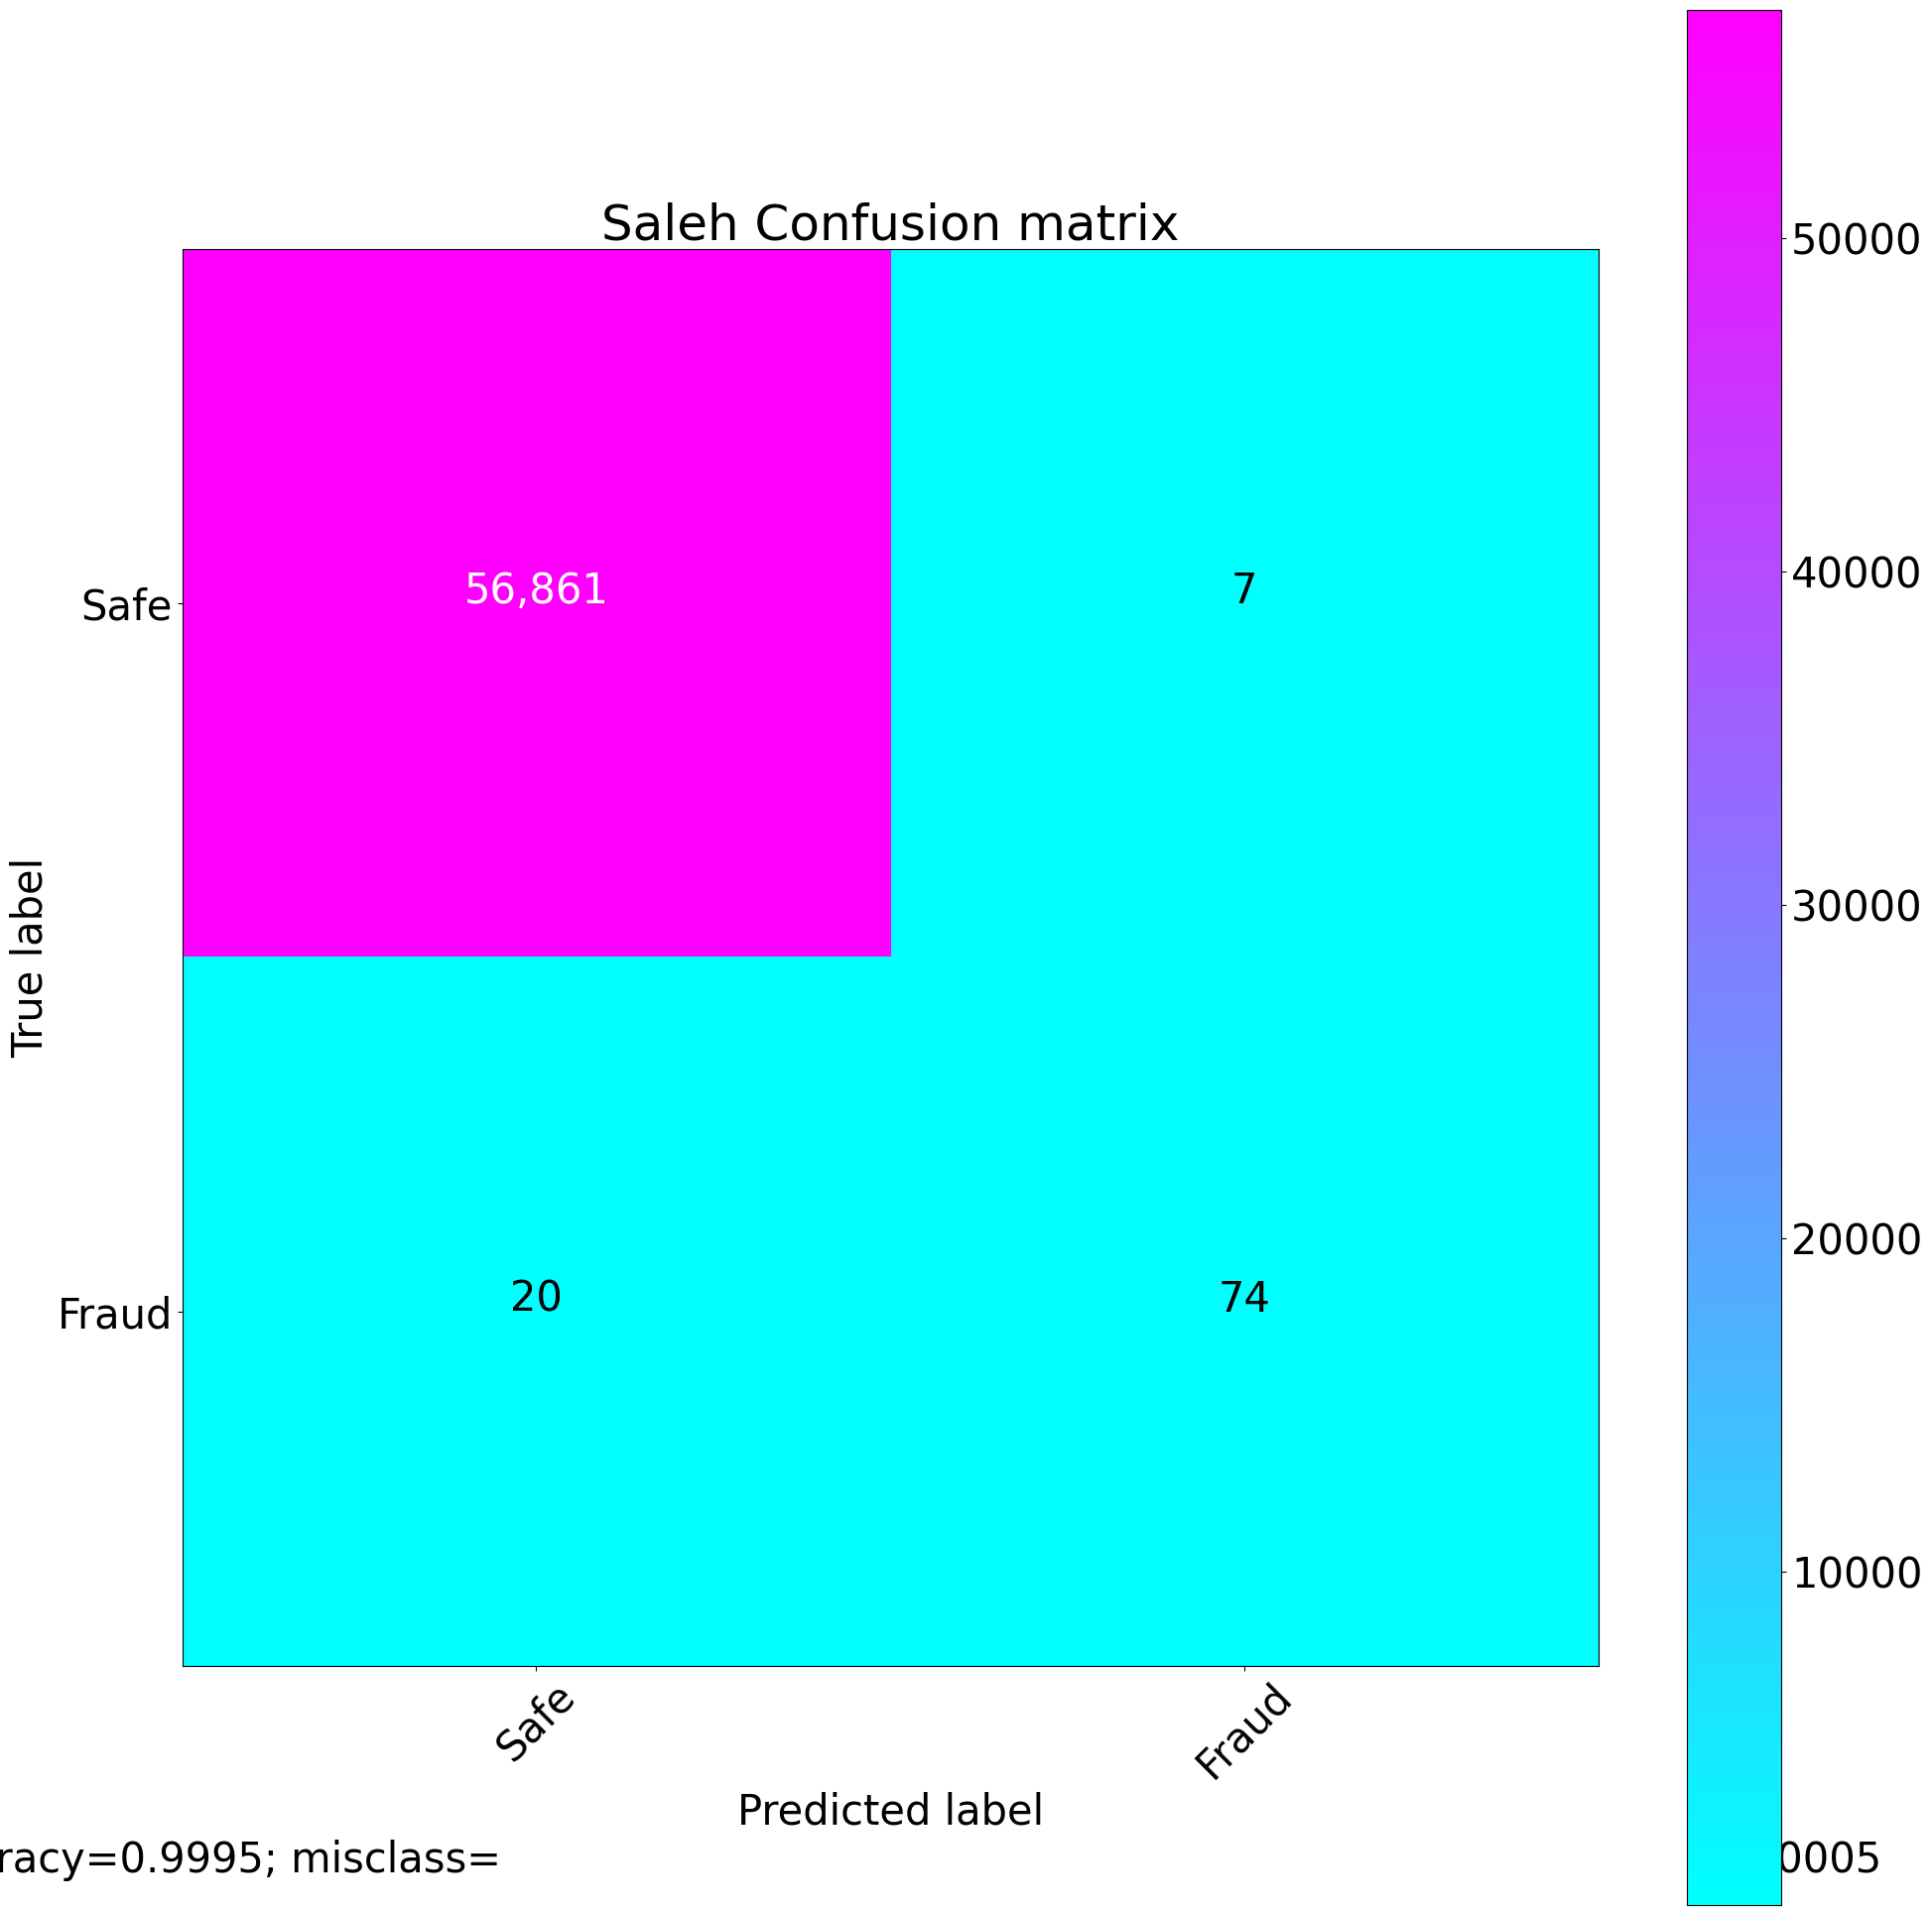

In [33]:
plot_confusion_matrix(cm1,
                          ["Safe","Fraud"], # use y_train.unique()  to know order of labels
                          title='Saleh Confusion matrix',
                          cmap=None,
                          normalize=False)

#error= 27,10
#accuraate= 74

In [50]:
from sklearn.ensemble import BaggingClassifier
hp_bagging={'n_estimators':[3,4,5,6]}
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,cv=5,
                                       scoring='roc_auc',n_jobs=1,verbose=1)
tree_bagg=Tree_Gridsearch_paramters.fit(x_train,y_train)
y_pred =tree_bagg.predict(x_test)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))

#Calculate sensitivity and specificity

total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[[56865     3]
 [   20    74]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56868
       Fraud       0.96      0.79      0.87        94

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9995962220427653
Sensitivity :  0.9999472462544841
Specificity :  0.7872340425531915


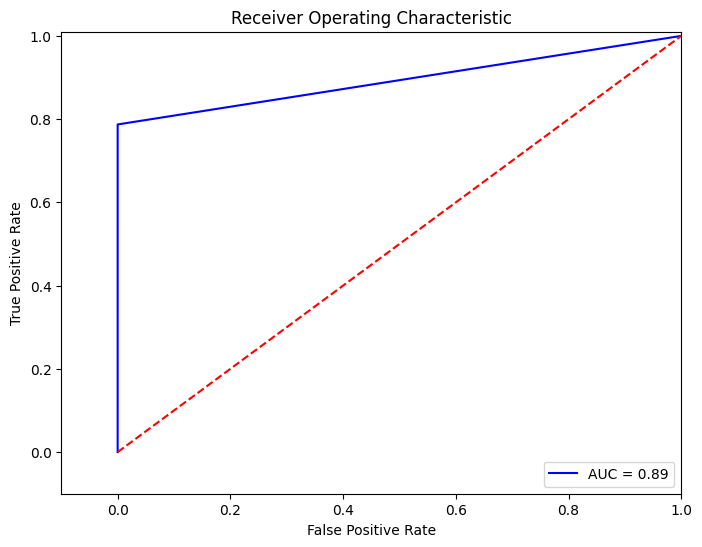

In [52]:
from sklearn.metrics import confusion_matrix,precision_recall_curve,auc,roc_auc_score,roc_curve,recall_score,classification_report 

plt.rcParams.update({'font.size': 10})

fpr, tpr, thresholds = roc_curve(y_test.ravel(),y_pred)
roc_auc = auc(fpr,tpr)

# Plot ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.show()